# Tests of running synthpop

In [1]:
import synthpop
import matplotlib.pyplot as plt
from gaianir_open_clusters.config import SYNTHPOP_CONFIG_DIRECTORY, SYNTHPOP_DEFAULT_CONFIG, SYNTHPOP_SPECIFIC_CONFIG
from gaianir_open_clusters.util import HiddenPrints

/home/emily/code/gaianir-open-clusters/.venv/lib/python3.13/site-packages/pydantic/_internal/_config.py:386: UserWarning: Valid config keys have changed in V2:
* 'keep_untouched' has been renamed to 'ignored_types'
  warnings.warn(message, UserWarning)


In [3]:
# Switches off the synthpop logging

from synthpop.synthpop_utils.synthpop_logging import logger
import logging

def dummy_func(*args, **kwargs):
    pass

logger.setLevel(logging.ERROR)
logger.stream_logger.setLevel(logging.ERROR)
# logger.filelogger.setLevel(logging.ERROR)
logger.debugger.setLevel(logging.ERROR)
logger.create_info_section = dummy_func
logger.create_info_subsection = dummy_func

In [4]:
model = synthpop.SynthPop(
        specific_config=SYNTHPOP_SPECIFIC_CONFIG,
        default_config=SYNTHPOP_DEFAULT_CONFIG,
        # extinction_map_kwargs=dict(name="no_extinction"),
    )
model.init_populations()

 25666 - Location or solid_angle_sr are not  defined in the settings! Can not run main() or process_all()
/home/emily/code/gaianir-open-clusters/prototypes/synthpop/../../.venv/lib/python3.13/site-packages/synthpop/modules/evolution/mist.py:361: SyntaxWarning: invalid escape sequence '\s'
  df = pandas.read_csv(filename, sep='\s+', comment='#',
/home/emily/code/gaianir-open-clusters/prototypes/synthpop/../../.venv/lib/python3.13/site-packages/synthpop/modules/evolution/mist.py:361: SyntaxWarning: invalid escape sequence '\s'
  df = pandas.read_csv(filename, sep='\s+', comment='#',


ConnectTimeout: HTTPSConnectionPool(host='mist.science', port=443): Max retries exceeded with url: /data/tarballs_v1.2/MIST_v1.2_vvcrit0.4_basic_isos.txz (Caused by ConnectTimeoutError(<HTTPSConnection(host='mist.science', port=443) at 0x7f1ef7870590>, 'Connection to mist.science timed out. (connect timeout=None)'))

In [ ]:
result = model.process_location(
    l_deg=10, b_deg=0, solid_angle=1 / 60**2, save_data=False
)[0]

In [ ]:
print(len(result))

15913


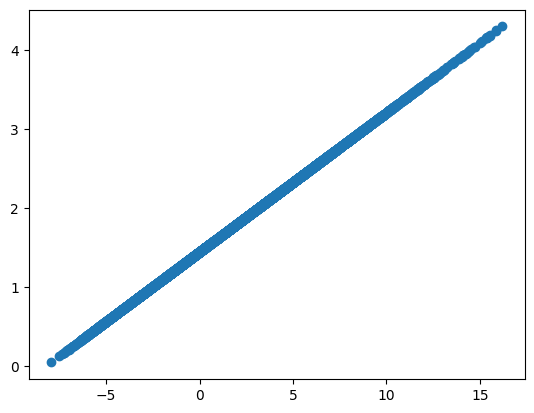

In [ ]:
plt.scatter(result['x'], result['y'])

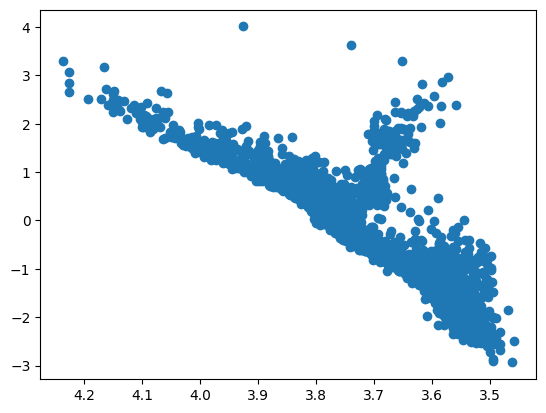

In [ ]:
plt.scatter(result['logTeff'], result['logL'])
plt.gca().invert_xaxis()

In [42]:
result.columns

Index(['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist',
       'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR',
       'A_None', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius',
       'phase', 'Gaia_G_EDR3', 'Gaia_BP_EDR3', 'Gaia_RP_EDR3', '2MASS_J',
       '2MASS_H', '2MASS_Ks'],
      dtype='object')

<Axes: >

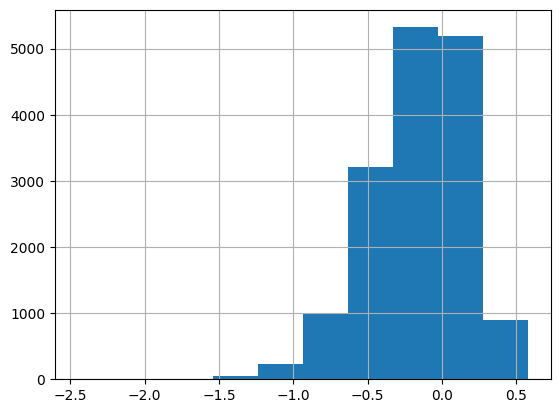

In [43]:
result['Fe/H_evolved'].hist()

:tada: it works!!